# GWHD Score Validation

This notebook validates the score on Global Wheat Head by checking whether mean $S_{img}$ tracks domain AP in the expected direction.

The seven-domain values below are taken from the GWHD domain analysis reported in the paper draft:
- lower AP should correspond to higher mean $S_{img}$
- the hardest domain is `arvalis 2`
- the easiest domain is `rres 1`

In [ ]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

PROJECT_ROOT = Path('/home/khanh/Projects/DifficultyAgri')
SOURCE_TEX_PATH = PROJECT_ROOT / 'docs/Research_Paper/MinImageScorer_GCCE2026_v2.tex'


def extract_domain_table_from_tex(tex_path: Path) -> pd.DataFrame:
    if not tex_path.exists():
        raise FileNotFoundError(f'Missing source file: {tex_path}')

    rows = []

    for raw_line in tex_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if '&' not in line:
            continue

        parts = [part.strip().replace('\\', '') for part in line.split('&')]
        if len(parts) != 5:
            continue

        domain, n_images, ap, ap50, mean_score = parts
        try:
            rows.append(
                {
                    'domain': domain.replace('~', ' ').strip(),
                    'n_images': int(n_images),
                    'AP': float(ap),
                    'AP50': float(ap50),
                    'mean_S_img': float(mean_score),
                }
            )
        except ValueError:
            continue

    if not rows:
        raise ValueError(f'No domain rows were parsed from {tex_path}')

    domain_df = pd.DataFrame(rows)
    domain_df['rank_by_AP'] = domain_df['AP'].rank(ascending=False, method='min').astype(int)
    domain_df['rank_by_score'] = domain_df['mean_S_img'].rank(ascending=False, method='min').astype(int)
    return domain_df.sort_values('AP', ascending=False).reset_index(drop=True)


domain_df = extract_domain_table_from_tex(SOURCE_TEX_PATH)
display(domain_df)

spearman_rho = domain_df['AP'].corr(domain_df['mean_S_img'], method='spearman')
pearson_r = domain_df['AP'].corr(domain_df['mean_S_img'], method='pearson')

hardest = domain_df.loc[domain_df['AP'].idxmin()]
easiest = domain_df.loc[domain_df['AP'].idxmax()]

print(f'Spearman rho(AP, mean_S_img) = {spearman_rho:.2f}')
print(f'Pearson r(AP, mean_S_img) = {pearson_r:.2f}')
print(f'Hardest domain: {hardest.domain} | AP = {hardest.AP:.3f} | mean_S_img = {hardest.mean_S_img:.3f}')
print(f'Easiest domain: {easiest.domain} | AP = {easiest.AP:.3f} | mean_S_img = {easiest.mean_S_img:.3f}')

ValueError: No domain rows were parsed from /home/khanh/Projects/DifficultyAgri/docs/Research_Paper/MinImageScorer_GCCE2026_v2.tex

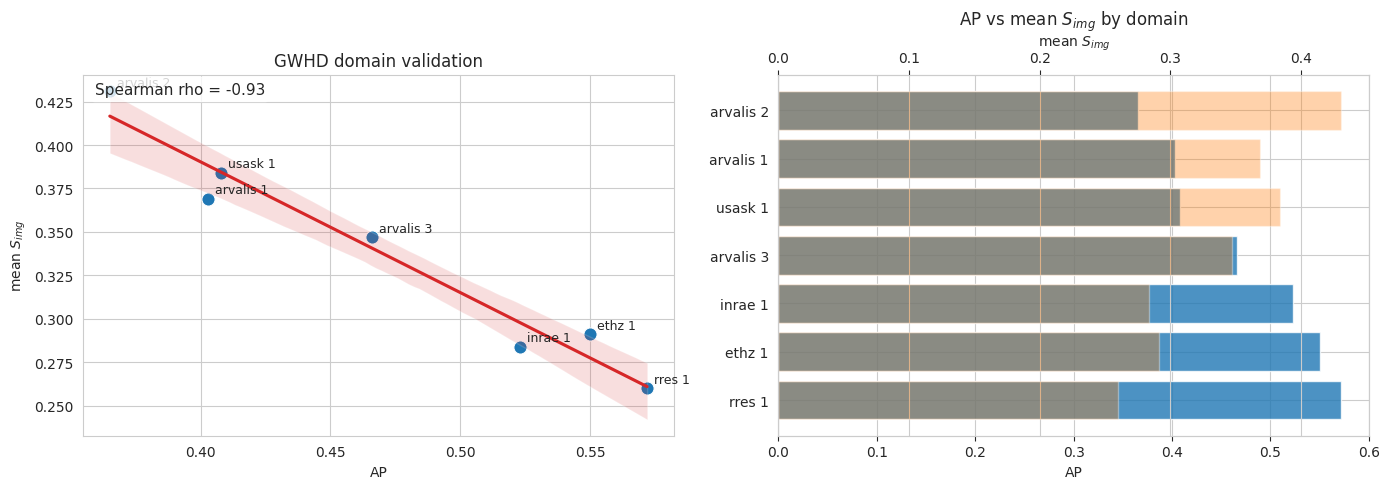

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=domain_df, x='AP', y='mean_S_img', s=90, ax=ax[0])
sns.regplot(data=domain_df, x='AP', y='mean_S_img', scatter=False, ax=ax[0], color='tab:red')
for _, row in domain_df.iterrows():
    ax[0].annotate(row['domain'], (row['AP'], row['mean_S_img']), textcoords='offset points', xytext=(5, 4), fontsize=9)
ax[0].set_title('GWHD domain validation')
ax[0].set_xlabel('AP')
ax[0].set_ylabel('mean $S_{img}$')
ax[0].text(0.02, 0.98, f'Spearman rho = {spearman_rho:.2f}', transform=ax[0].transAxes, va='top', ha='left', fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plot_df = domain_df.sort_values('AP', ascending=True)
ax[1].barh(plot_df['domain'], plot_df['AP'], label='AP', color='tab:blue', alpha=0.8)
ax2 = ax[1].twiny()
ax2.barh(plot_df['domain'], plot_df['mean_S_img'], label='mean $S_{img}$', color='tab:orange', alpha=0.35)
ax[1].set_title('AP vs mean $S_{img}$ by domain')
ax[1].set_xlabel('AP')
ax2.set_xlabel('mean $S_{img}$')
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Interpretation

The table and plot should show the expected inverse trend: lower AP domains have higher mean $S_{img}$ values. In the reported GWHD analysis, `arvalis 2` is the hardest source domain and `rres 1` is the easiest, which matches the score ordering.